#  Memo No. 4: MSD and PDF of CMB Data
Kit M. Gerodias

This notebook uses the same SMICA pipeline from Planck PR2 data. Most scripts are a continuation of the previous memos. Some equations were also added in the markdown.

The MSD function has been corrected and updated. PDF plots has also been added for the first time. 

The effects of changing the parameters $\mu$, $\beta$, and $A$ on the MSD fit were also investigated.

In [1]:
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from healpy.newvisufunc import projview, newprojplot

from astropy.io import fits
import pandas as pd

from scipy.optimize import curve_fit
import scipy.special as scsp

import scipy.stats as stats
from statsmodels.graphics.tsaplots import plot_acf
from scipy.fft import fft, fftfreq
import inspect

### MSD Implementation

For calculating MSD, the function `msd(t, x, ...)` is implemented based on the equation:

$$ MSD(\Delta) = \frac{1}{N-\Delta} \sum_{i=1}^{N-\Delta} (x[i + \Delta] - x[i] )^2 $$

Theoretical MSD used is expressed as follows

$$ MSD  = \Gamma(\mu) t^{\mu -1} \beta^{-\mu} e^{\frac{-\beta}{t}} $$

Adding a normalization factor, $A$, MSD becomes

$$ MSD  = A \Gamma(\mu) t^{\mu -1} \beta^{\mu} e^{\frac{-\beta}{t}} $$

### PDF Implementation

The probability density function, P, at a particular lag $\Delta$ is expressed as

$$ P(dx, \Delta) = \frac{1}{\sqrt{2 \pi MSD(\Delta)}} \exp\biggl[ -\frac{dx^2}{2MSD(\Delta)} \biggr]$$

where $dx = x[i + \Delta] - x[i]$.

Since the data points may be gaussian, I also fit a Gaussian function where $\mu$ and $\sigma$ describes the mean and standard deviation of the distribution at a particular lag, respectively. The Gaussian is 

$$ f_G(t) = \frac{1}{\sqrt{2 \pi \sigma^2}} \exp\biggl[ -\frac{(t-\mu)^2}{2\sigma^2} \biggr]$$

NOTE: I'm using the same parameter $\mu$ for the $\mu$ of MSD and mean $\mu$. A bit sloppy on my part

In [2]:
def msd_old(t,x):
    # inserted t is the time
    result = np.zeros_like(x)
    std = np.zeros_like(x)
    #calculates MSD and takes sigma for every 
    for i in range(1,len(x)):
        sq_dx = (x[i:] - x[:-i])**2
        result[i] = np.average(sq_dx)
        std[i] = np.std(sq_dx, ddof=1)/ np.sqrt(len(sq_dx))

    #calculates lag unit
    # here, t becomes lag value
    t = np.cumsum(np.diff(t))
    return t, result[1:], std[1:]

def msd(t, x, max_lag_points=None, max_lag_seconds=None, cap_at_half_turn=True):
    """
    Compute the mean square displacement mean of (x[i+Δ] - x[i])^2 for a given lag Δ.
    
    Parameters
    ----------
    t : array-like
    Time or in this case, angular scale array
    x : array-like
    Trajectory or fluctuations values
    max_lag_points : int or None
    Set number of datapoints
    max_lag_seconds : int or None
    Set maximum lag scale
    cap_at_half_turn : bool
    True avoids double counting 
    and limits calculation to half of the total time or scale

    Returns
    ----------
    t_lag : ndarray
    lag time values
    result : ndarray
    empirical mean square displacement values
    std : ndarray
    standard deviation of MSD at a lag time

    """

    x = np.asarray(x)
    t = np.asarray(t)
    N = len(x)

    result = np.zeros_like(x, dtype=float)
    std = np.zeros_like(x, dtype=float)

    # Decide max lag in points
    if max_lag_points is None:
        if max_lag_seconds is None:
            max_lag_points = N - 1
        else:
            dt = np.median(np.diff(t))  # if t is uniform angle grid, this is dtheta
            max_lag_points = int(np.floor(max_lag_seconds / dt))

    max_lag_points = int(np.clip(max_lag_points, 1, N - 1))

    # For a circle, lags beyond N//2 are the "long way around" (often redundant)
    if cap_at_half_turn:
        max_lag_points = min(max_lag_points, N // 2)

    # Wrapped (circular) MSD
    for i in range(1, max_lag_points + 1):
        dx = np.roll(x, -i) - x      # x[(j+i) mod N] - x[j]
        sq_dx = dx**2
        result[i] = np.average(sq_dx)
        std[i] = np.std(sq_dx, ddof=1) / np.sqrt(len(sq_dx))  # len(sq_dx)=N

    # Lag coordinate: use original "lag unit" idea, but make it match max_lag_points
    # If t is uniform grid, lag ≈ i * median(diff(t))
    dt = np.median(np.diff(t))
    t_lag = dt * np.arange(1, max_lag_points + 1)

    return t_lag, result[1:max_lag_points+1], std[1:max_lag_points+1]

#fit theoretical MSD

# def msd_model(t, A, mu, beta):
#     return A * t**(mu - 1) * beta**mu * np.exp(-beta / t)

def msd_model(t, A, mu, beta):
    """
    Calculate theoretical MSD based on the equation

    Parameters
    ----------
    t : array-like
    Time or in this case, angular scale array
    A : float
    Normalization value
    mu : float
    mu parameter
    beta : float
    beta parameter

    Returns
    ----------
    : ndarray
    theoretical MSD values    
    """
    return A * scsp.gamma(mu) * t**(mu - 1) * beta**(-mu) * np.exp(-beta / t)

In [3]:
def displacement_pdf(
    t,
    x,
    lag_scale_of_concern,
    bins=50,
    range=None,
    density=True,
    cap_at_half_turn=True
):
    """
    Compute PDF of displacements Δx = x(t+τ) - x(t) for a given lag τ (in points).
    
    Parameters
    ----------
    t : array-like
    Time (or angle) array
    x : array-like
    Trajectory values
    lag_scale_of_concern : int
    Which lag time?
    bins : int or array
    Histogram bins
    range : tuple or None
    Histogram range
    density : bool
    If True, normalize to PDF
    cap_at_half_turn : bool
    For circular data, prevent long-way-around lags
    
    Returns
    -------
    bin_centers : ndarray
    Centers of displacement bins
    pdf : ndarray
    Probability density function values
    displacements : ndarray
    Raw displacement samples
    """
    
    x = np.asarray(x)
    t = np.asarray(t)
    N = len(x)
    lag_index = np.argmin(np.abs(t - lag_scale_of_concern))
    
    # Safety checks
    if lag_index < 1 or lag_index >= N:
        raise ValueError("lag_index must be between 1 and N-1")
        
    if cap_at_half_turn:
        lag_index = min(lag_index, N // 2)
        
    # Compute displacements (wrapped, same as MSD)
    dx = np.roll(x, - lag_index) - x
    
    # Histogram
    hist, bin_edges = np.histogram(
        dx,
        bins=bins,
        range=range,
        density=density
        )
        
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
            
    return bin_centers, hist, dx, bin_edges

In [4]:
def gaussian(x, mu, sigma):
    return (1 / (np.sqrt(2*np.pi) * sigma)) * np.exp(-(x - mu)**2 / (2 * sigma**2))

def gaussian_msd(dx, sigma):
    'sigma is msd'
    return (1 / (np.sqrt(2*np.pi) * sigma)) * np.exp(-dx**2 / (2 * sigma**2))

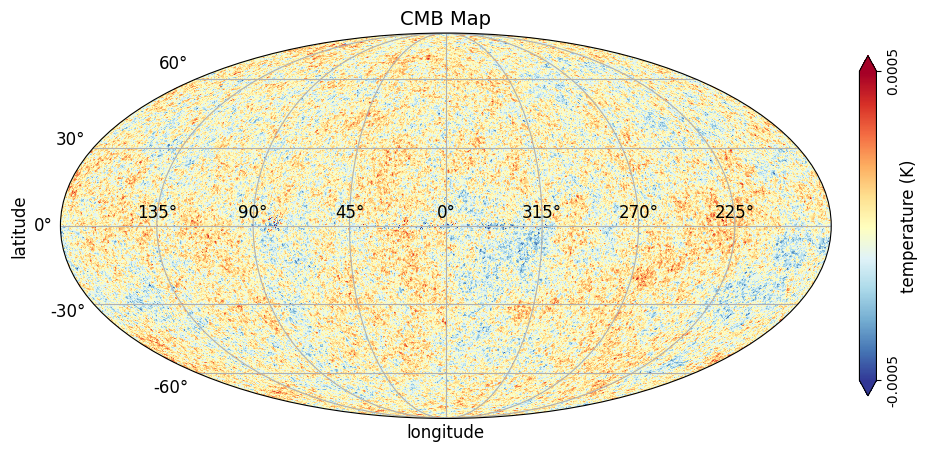

In [6]:
projview(
    cmb_map,
    coord=["G"],
    graticule=True,
    graticule_labels=True,
    unit="temperature (K)",
    xlabel="longitude",
    ylabel="latitude",
    cb_orientation="vertical",
    min=-5e-4,
    max=5e-4,
    #norm = "symlog",
    latitude_grid_spacing=30,
    longitude_grid_spacing= 45,
    projection_type="mollweide",
    title="CMB Map",   
    cmap = 'RdYlBu_r',
);

# cmap: bwr?, coolwarm?, RdYlBu_r?

__Reminder__: the temperature anisotropy is zeroed in around __2.72548 K__.

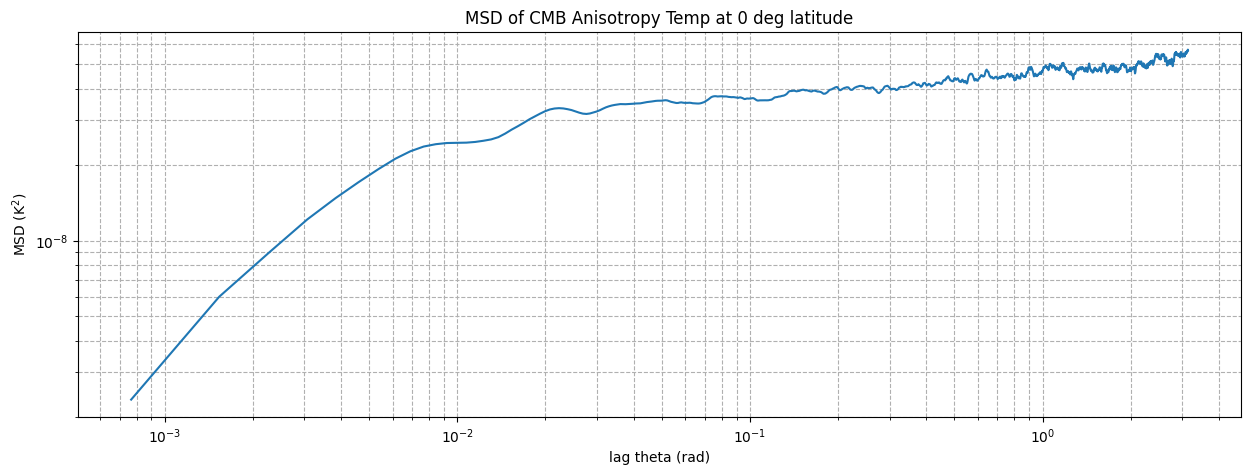

CPU times: user 368 ms, sys: 11.4 ms, total: 380 ms
Wall time: 827 ms


In [12]:
%%time
plt.figure(figsize=(15,5))
lag_theta, cmb_msd, cmb_std = msd(theta, cmb_map[strip])
lag_theta = np.radians(lag_theta)
# plt.scatter(np.radians(theta[1:]),cmb_msd, s=1)
plt.loglog(lag_theta,cmb_msd)
# plt.scatter(np.log10(np.radians(theta[1:])),np.log10(cmb_msd), s=1)

plt.xlabel('lag theta (rad)')
plt.ylabel('MSD (K$^2$)')
plt.title('MSD of CMB Anisotropy Temp at 0 deg latitude')
# plt.xlim(6.2)
# plt.ylim(0, 1e-9)
plt.grid(True, which='both', ls='--')
plt.show()

# Parameters $\mu$ and $\beta$
### Looking into how the parameters $\mu$ and $\beta$ behave

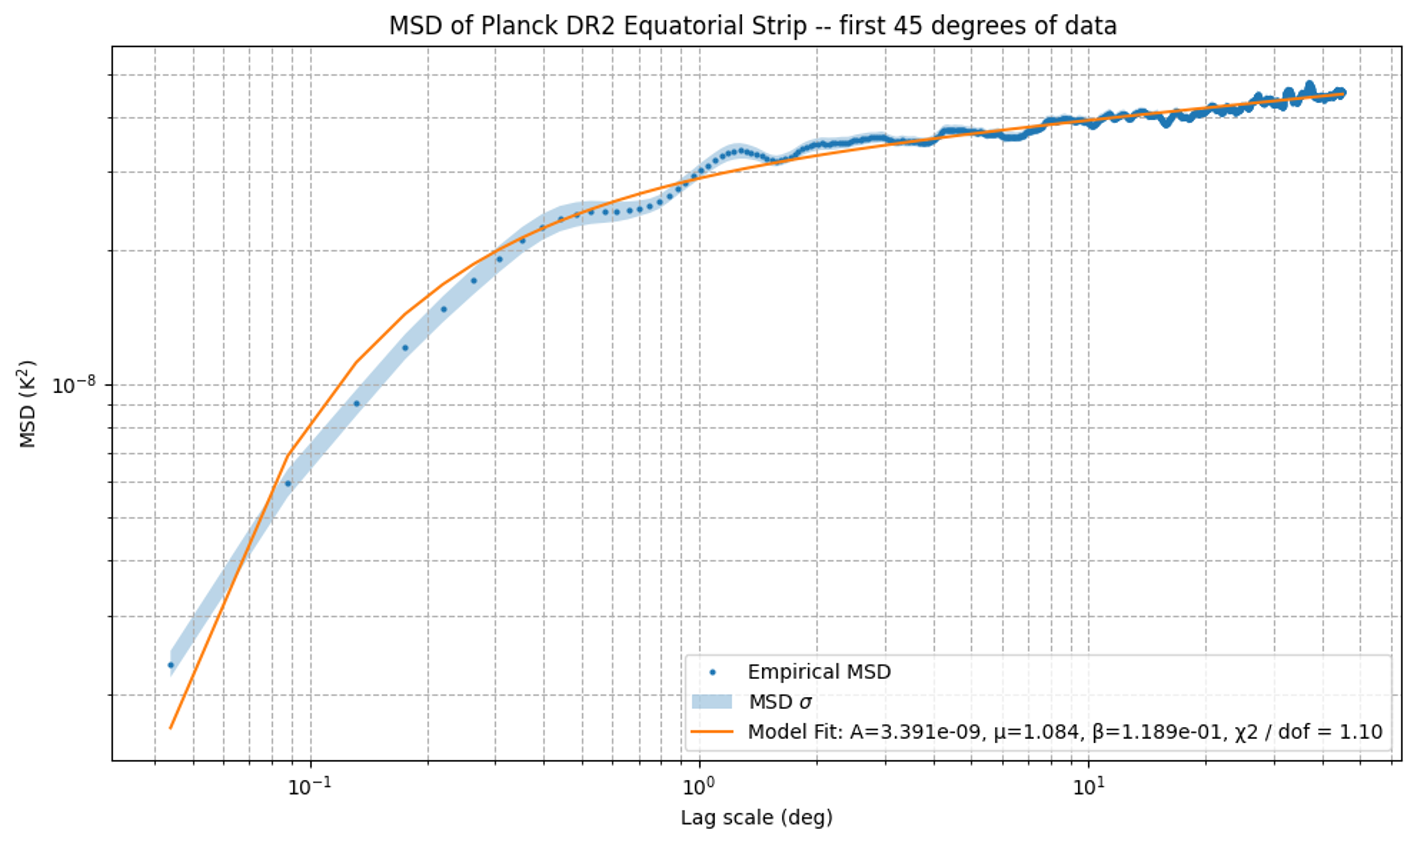

# increasing beta

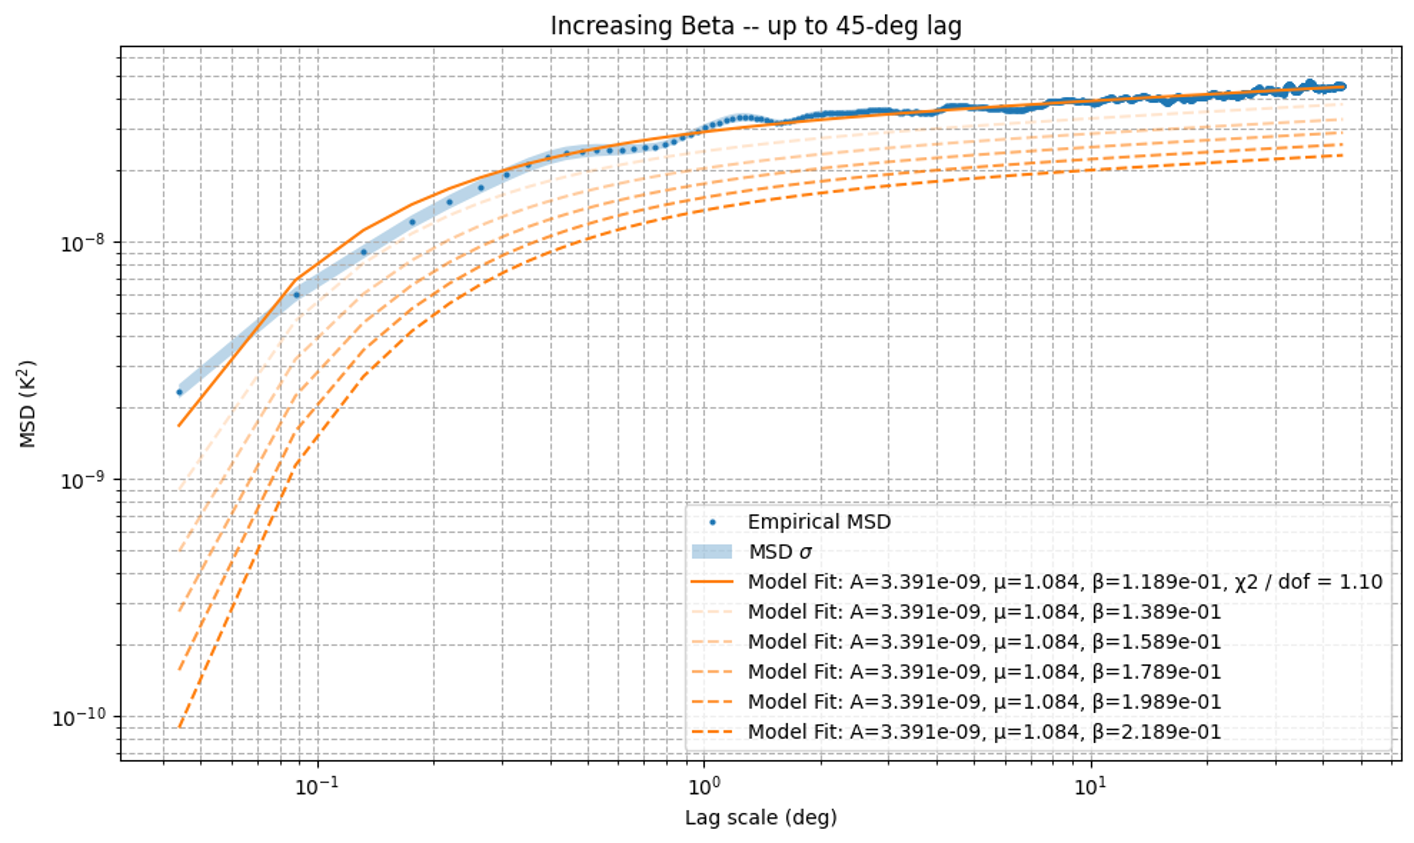

# decreasing beta

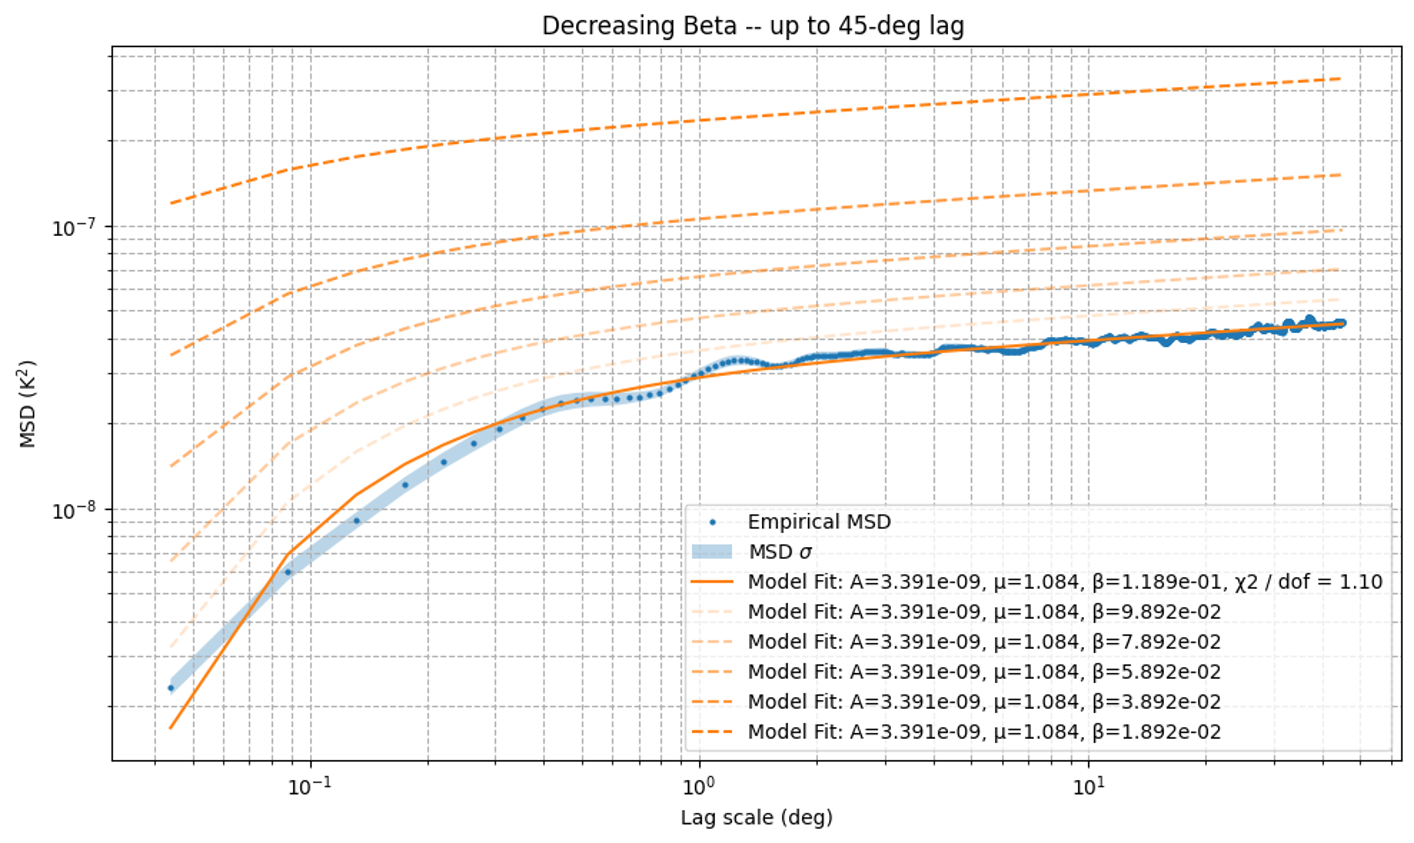

# increasing mu

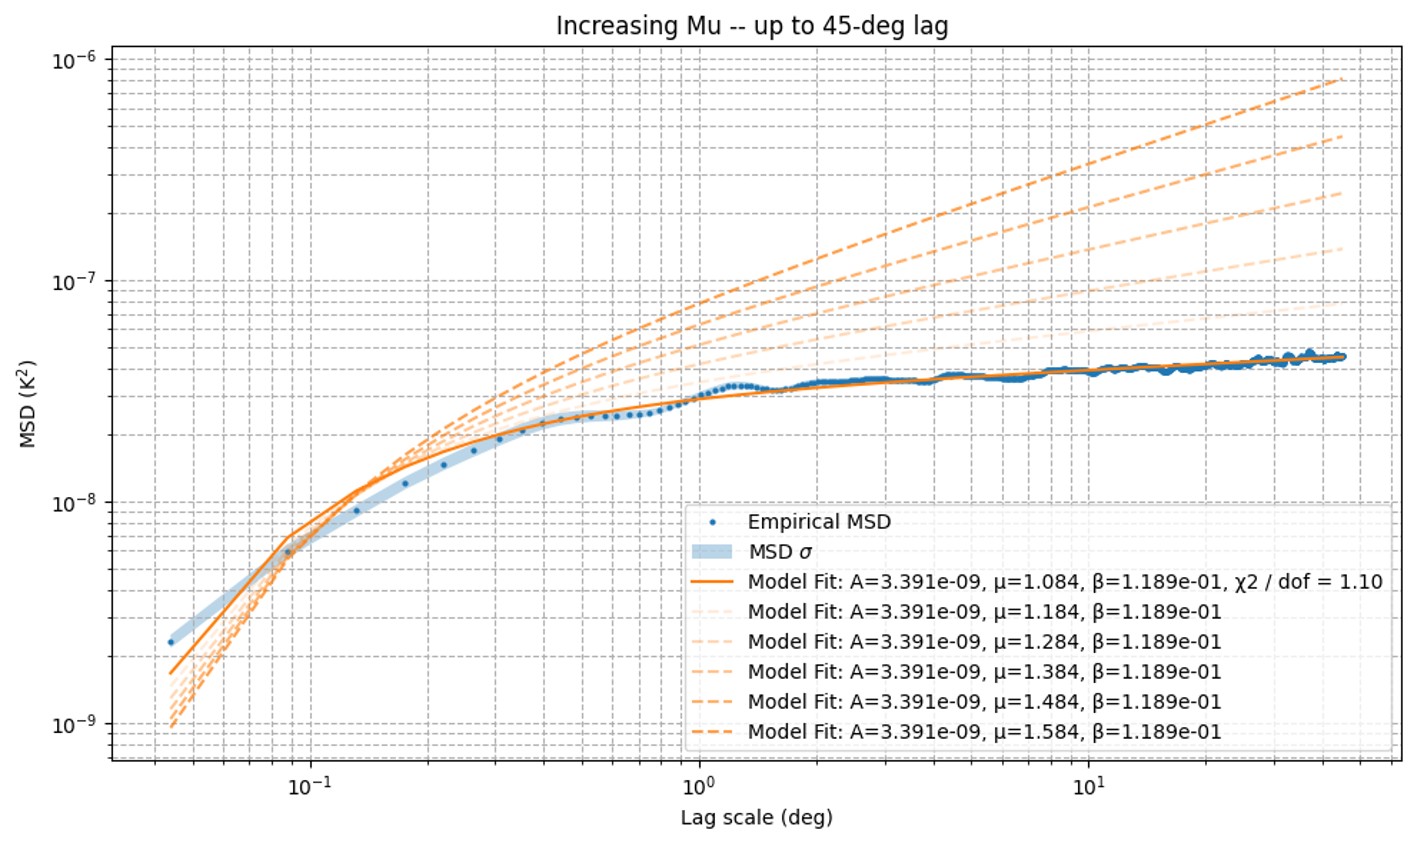

# decreasing mu

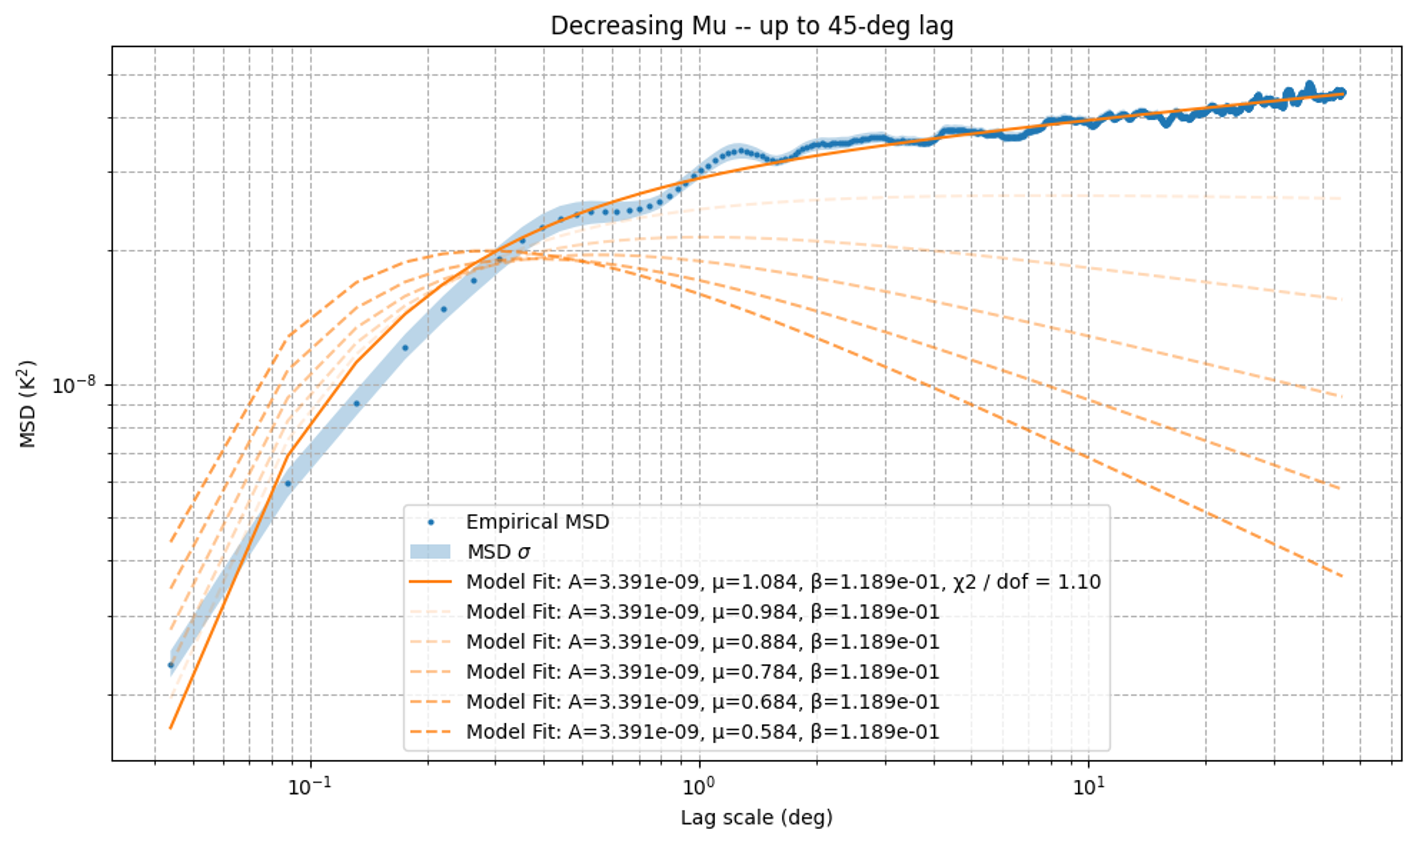

# increasing A

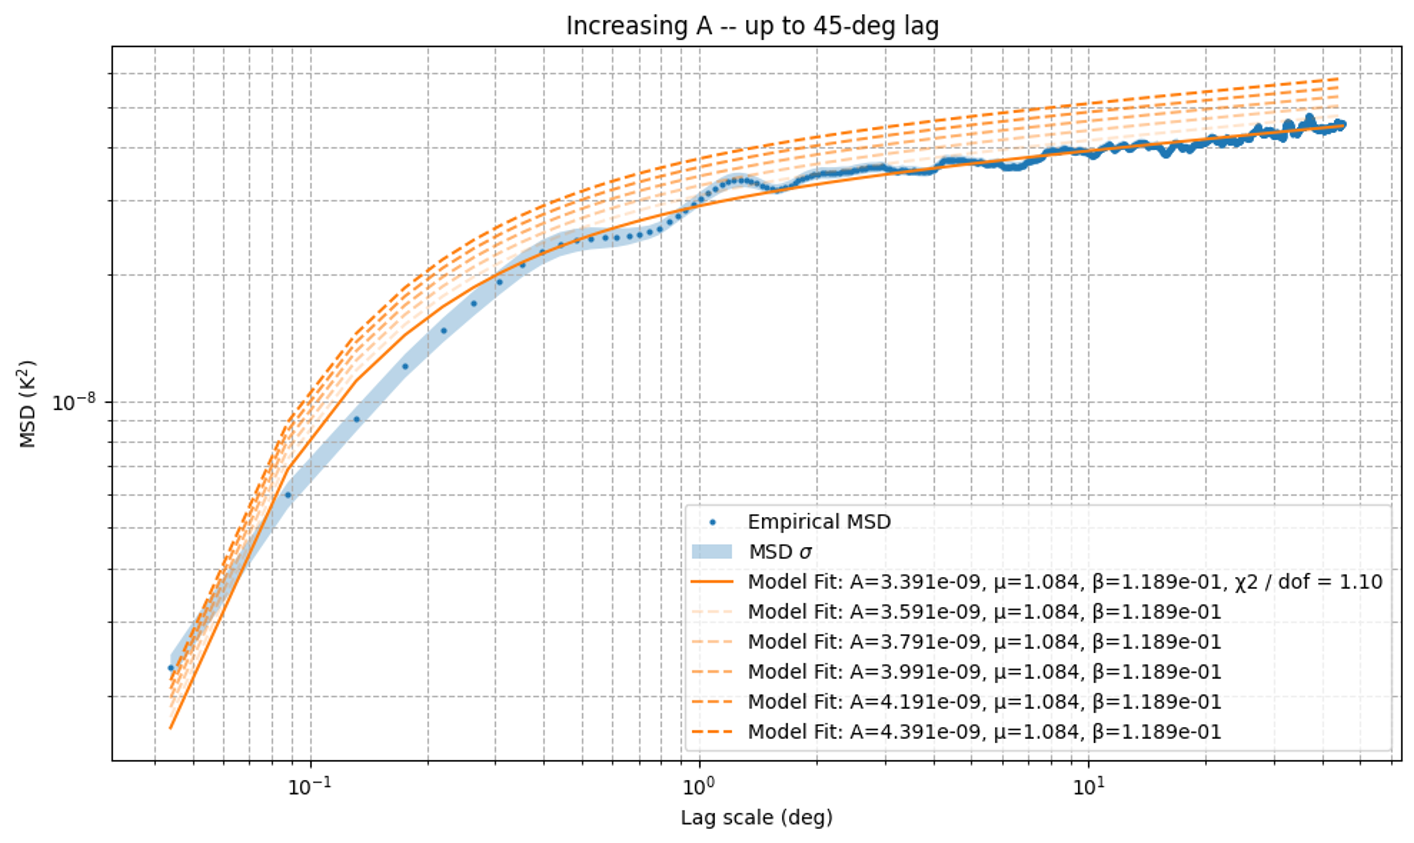

# decreasing A

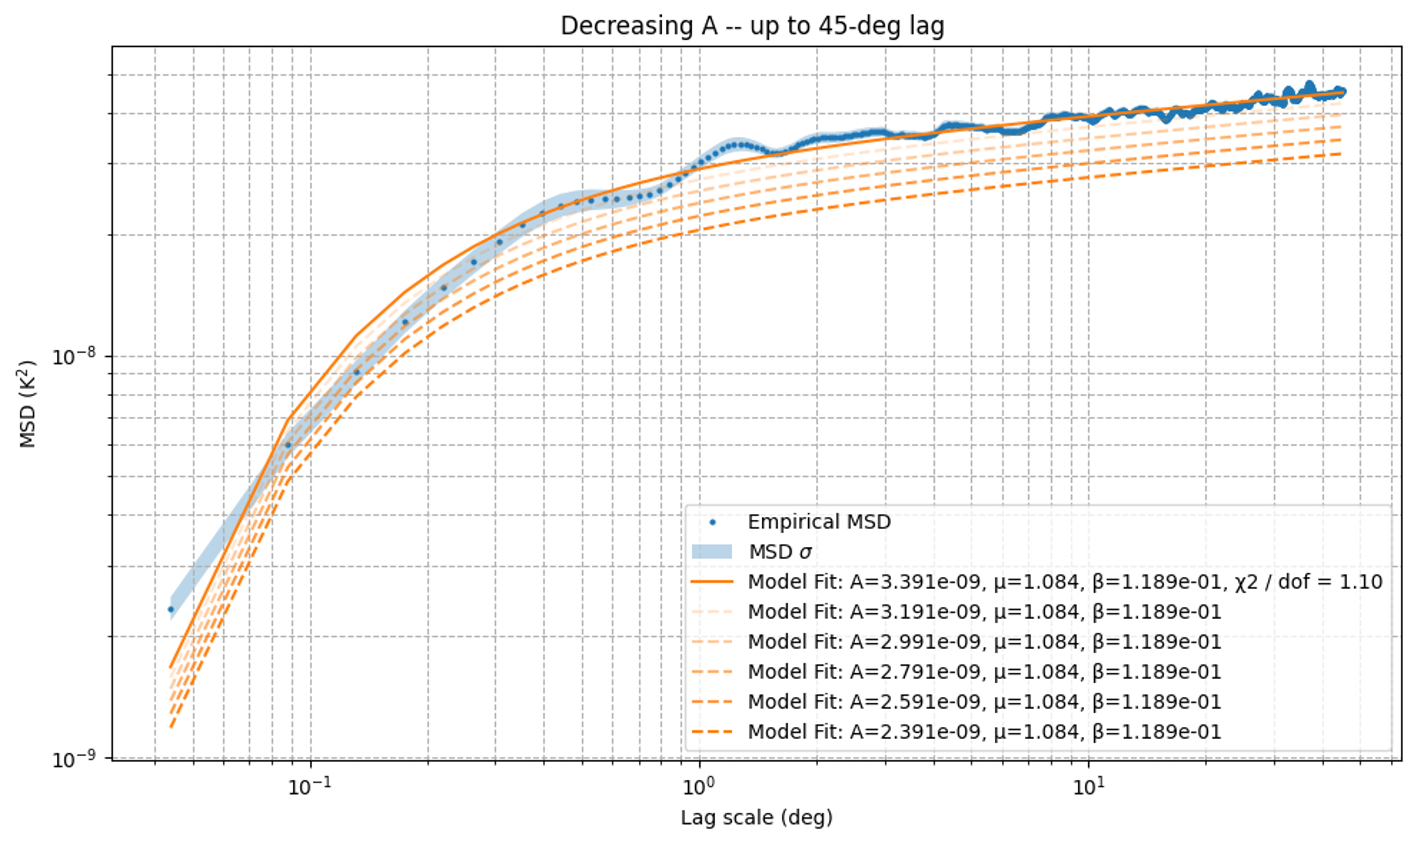

# When changing the maximum lag scale

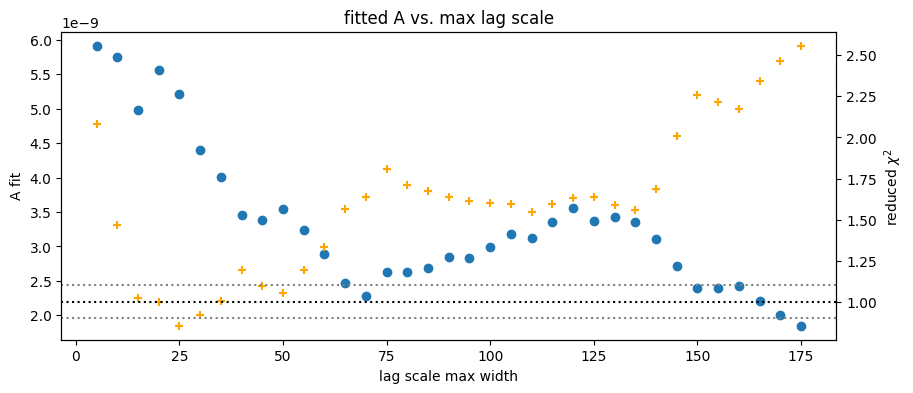

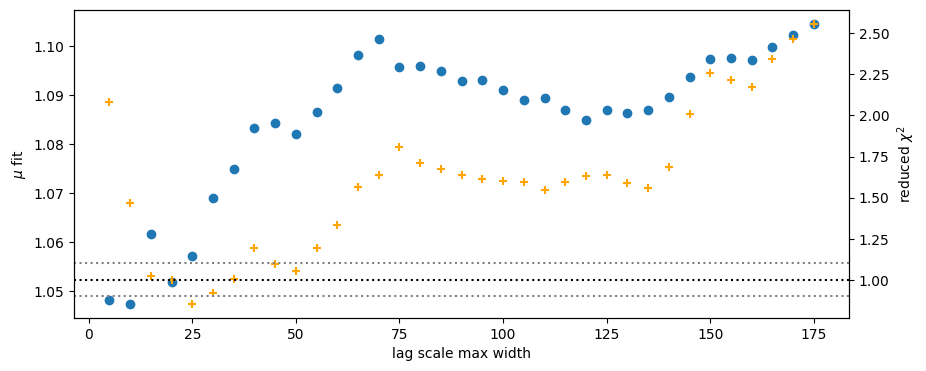

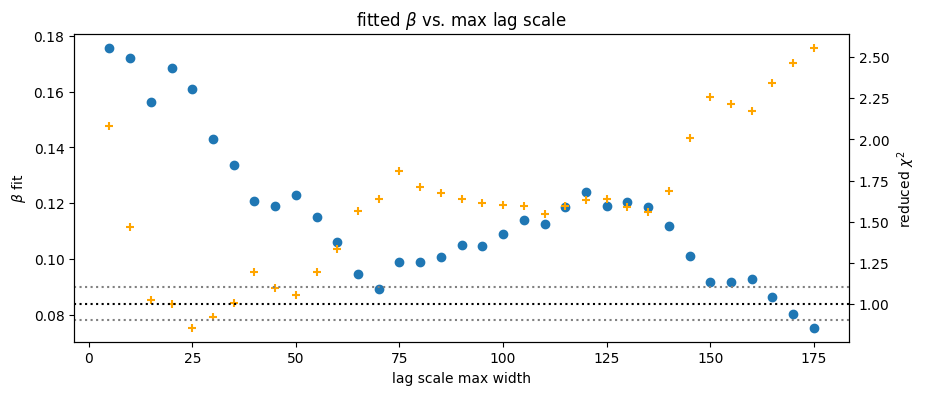

In [35]:

plt.figure(figsize=(10, 4))
plt.scatter(lag_scale_mat,A_fit)
plt.ylabel('A fit')
plt.xlabel('lag scale max width')
plt.twinx().scatter(lag_scale_mat, chi_sq_red, color = 'orange', marker = '+')
plt.ylabel(r'reduced $\chi^2$ ')
plt.axhline(0.9, color = 'gray', ls =':')
plt.axhline(1.0, color = 'black', ls = ':')
plt.axhline(1.1, color = 'gray', ls =':')
plt.title('fitted A vs. max lag scale')
plt.show()


plt.figure(figsize=(10, 4))
plt.scatter(lag_scale_mat,mu_fit)
plt.ylabel(r'$\mu$ fit')
plt.xlabel('lag scale max width')
plt.twinx().scatter(lag_scale_mat, chi_sq_red, color = 'orange', marker = '+')
plt.ylabel(r'reduced $\chi^2$ ')
plt.axhline(0.9, color = 'gray', ls =':')
plt.axhline(1.0, color = 'black', ls = ':')
plt.axhline(1.1, color = 'gray', ls =':')
plt.xlabel('lag scale max width')
plt.show()

plt.figure(figsize=(10, 4))
plt.scatter(lag_scale_mat,beta_fit)
plt.ylabel(r'$\beta$ fit')
plt.xlabel('lag scale max width')
plt.twinx().scatter(lag_scale_mat, chi_sq_red, color = 'orange', marker = '+')
plt.ylabel(r'reduced $\chi^2$ ')
plt.axhline(0.9, color = 'gray', ls =':')
plt.axhline(1.0, color = 'black', ls = ':')
plt.axhline(1.1, color = 'gray', ls =':')
plt.title(r'fitted $\beta$ vs. max lag scale')
plt.show()

#plt.scatter(lag_scale_mat, chi_sq_red)
#plt.show()

# Looking at different latitudes

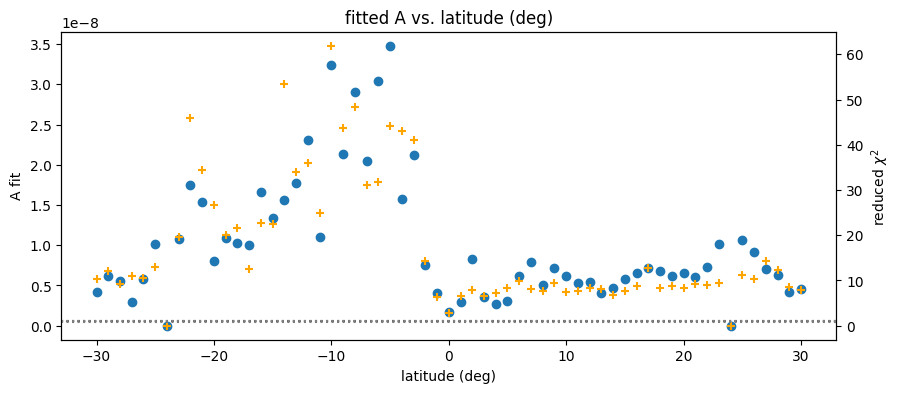

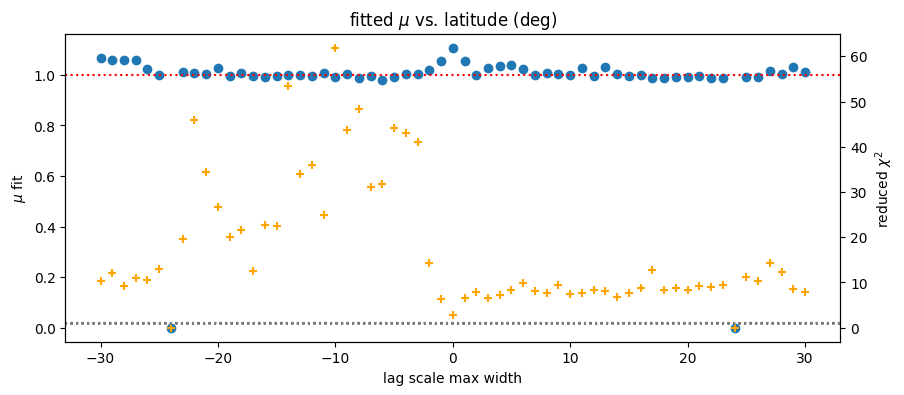

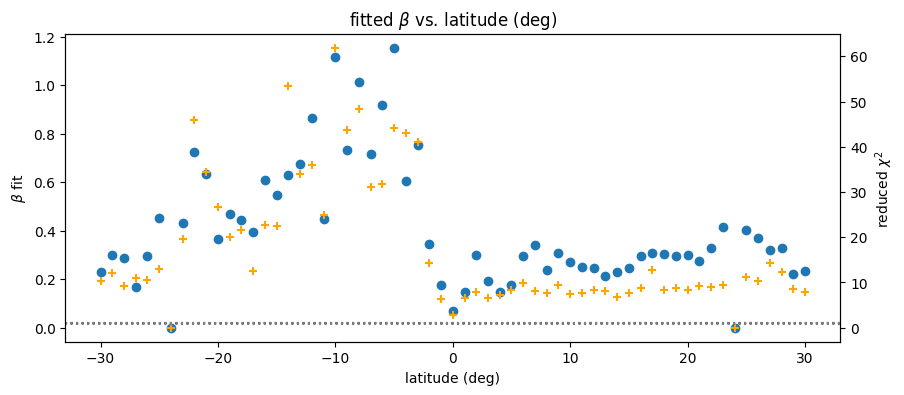

In [41]:
lat_val = (-theta_mat+90)
plt.figure(figsize=(10, 4))
plt.scatter(lat_val,A_fit)
plt.ylabel('A fit')
plt.xlabel('latitude (deg)')
plt.twinx().scatter(lat_val, chi_sq_red, color = 'orange', marker = '+')
plt.ylabel(r'reduced $\chi^2$ ')
plt.axhline(0.9, color = 'gray', ls =':')
plt.axhline(1.0, color = 'black', ls = ':')
plt.axhline(1.1, color = 'gray', ls =':')
plt.title('fitted A vs. latitude (deg)')
plt.show()


plt.figure(figsize=(10, 4))
plt.scatter(lat_val,mu_fit)
plt.ylabel(r'$\mu$ fit')
plt.xlabel('lag scale max width')
plt.axhline(1.0, c = 'red', ls=':')
plt.twinx().scatter(lat_val, chi_sq_red, color = 'orange', marker = '+')
plt.ylabel(r'reduced $\chi^2$ ')
plt.axhline(0.9, color = 'gray', ls =':')
plt.axhline(1.0, color = 'black', ls = ':')
plt.axhline(1.1, color = 'gray', ls =':')
plt.xlabel('latitude (deg)')
plt.title(r'fitted $\mu$ vs. latitude (deg)')
plt.show()

plt.figure(figsize=(10, 4))
plt.scatter(lat_val,beta_fit)
plt.ylabel(r'$\beta$ fit')
plt.xlabel('latitude (deg)')
plt.twinx().scatter(lat_val, chi_sq_red, color = 'orange', marker = '+')
plt.ylabel(r'reduced $\chi^2$ ')
plt.axhline(0.9, color = 'gray', ls =':')
plt.axhline(1.0, color = 'black', ls = ':')
plt.axhline(1.1, color = 'gray', ls =':')
plt.title(r'fitted $\beta$ vs. latitude (deg)')
plt.show()

#plt.scatter(lag_scale_mat, chi_sq_red)
#plt.show()